# M29: equivalent SDOF vs 3D NLTHA

Compares, for archetype **M29** in both directions:

1. **Peak displacements**: SDOF NLTHA (`Pushover_SDOF/ResultsM29x_SDOF`, `ResultsM29y_SDOF`) vs 3D NLTHA
   (`M29_biron_DispX.txt`, `M29_biron_DispY.txt`, largest peak over the braced nodes).
   The SDOF displacement is converted to the braced nodes with `SDOF_FACTOR`, by default
   $\Gamma \cdot \max\phi$ over the spring DOFs of the 2D pushover step the SDOF was built from.
   IMs or records the SDOF analyses have not reached yet are left out; rerun the notebook to update.
2. **Displaced shapes**: mean ± 2σ of the 3D NLTHA shapes (`M29_bironDispShapeX/Y.npy`) vs the equivalent
   static shape (`Pushover2D/pushover_results_M29x/y.txt`), on the plan of the 3D model, whole system
   and zoomed on the line analysed by the 2D model.

Helpers in [nltha_comparison.py](nltha_comparison.py).

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from nltha_comparison import *

mpl.rc('font', family='Times New Roman')
mpl.rc('mathtext', fontset='stix')
%matplotlib inline

In [2]:
MODEL       = 'M29'
DC_TARGET   = 12.0          # 2D pushover step (mm) of the SDOF calibration and of the static shape
SDOF_FACTOR = 'gamma_phi'   # SDOF -> braced-node displacement: 'gamma_phi', a number, or {'X': .., 'Y': ..}
SHAPE_IM    = 6             # intensity level (1-10) of the NLTHA displaced shapes
AMP         = None          # amplification of the displaced shapes (m per unit); None = automatic

## Peak displacements

In [3]:
comp = peak_comparison(MODEL, factor=SDOF_FACTOR, dc_target=DC_TARGET)
peak_table(comp)

X                                       Y                      \
   3D (mm) SDOF (mm) SDOF / 3D n 3D / SDOF 3D (mm) SDOF (mm) SDOF / 3D   
IM                                                                       
1    1.275     1.131     0.887     44 / 44   0.625     0.456     0.730   
2    3.085     2.759     0.894     44 / 44   2.540     2.547     1.003   
3    4.710     4.670     0.992     44 / 44   4.100     4.358     1.063   
4    6.215     6.167     0.992     44 / 44   5.160     5.753     1.115   
5    8.550     7.941     0.929     44 / 44   7.320     7.994     1.092   
6    9.935     9.796     0.986     44 / 44   8.890     9.261     1.042   
7   11.135    10.908     0.980     44 / 44  10.050    11.021     1.097   
8   12.460    12.096     0.971     44 / 44  10.670    11.310     1.060   
9   13.510    12.681     0.939     44 / 44  11.390    12.451     1.093   
10  14.155    13.552     0.957     44 / 44  11.325    12.311     1.087   

                
   n 3D / SDOF  
IM              
1      44 / 44  
2      44 / 44  
3      44 / 44  
4      44 / 44  
5      44 / 44  
6      44 / 44  
7      44 / 44  
8      44 / 44  
9      44 / 44  
10     44 / 44

Median (markers) and 16th–84th percentiles (bars) over the records.

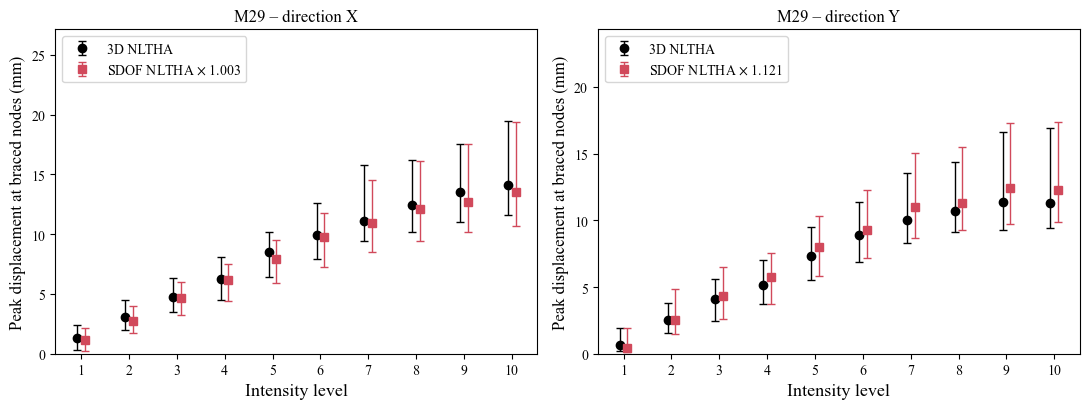

In [4]:
plot_peak_medians(MODEL, comp)
plt.show()

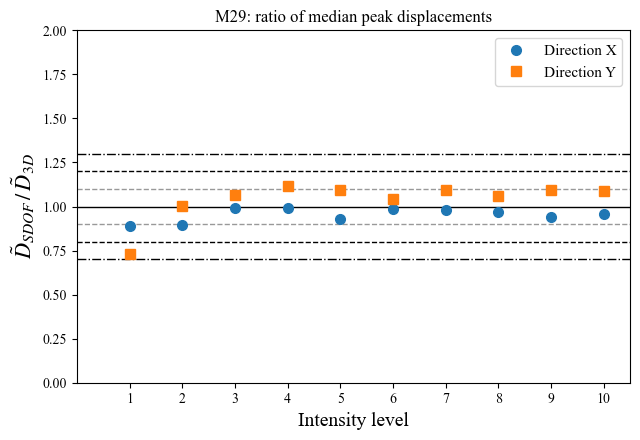

In [5]:
plot_peak_ratio(MODEL, comp)
plt.show()

Record by record (same record and IM in both analyses); dashed lines at ±20 %.

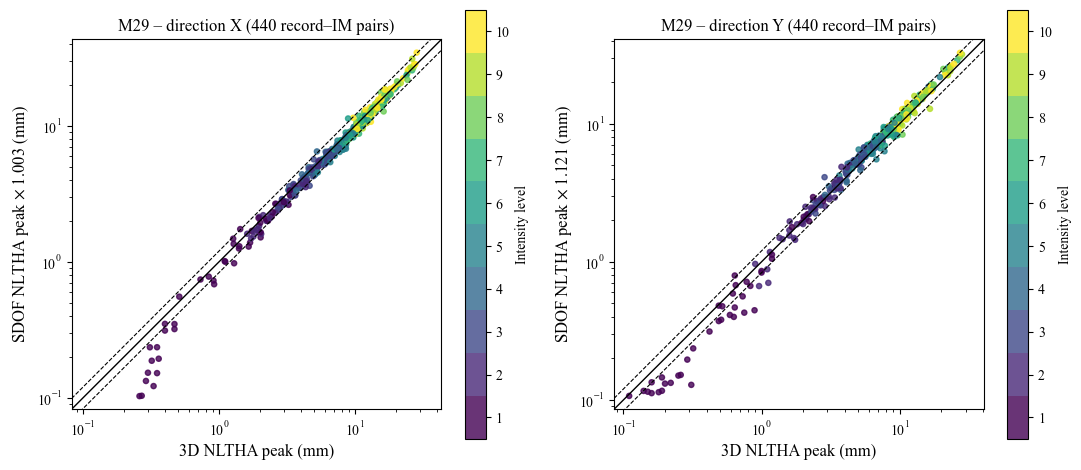

In [6]:
plot_peak_records(MODEL, comp)
plt.show()

## Displaced shapes

Both shapes are normalized to 1 at the marked node (the reference DOF of the 2D model). The static shape
is mapped onto the 3D plan through the analysed line of the 2D model (`nltha_lines` in
`Pushover2D/CS_Lumped_Iter_M29*_cont_PO.py`): pipes parallel to the excitation move rigidly, other
branches deform as the analysed line.

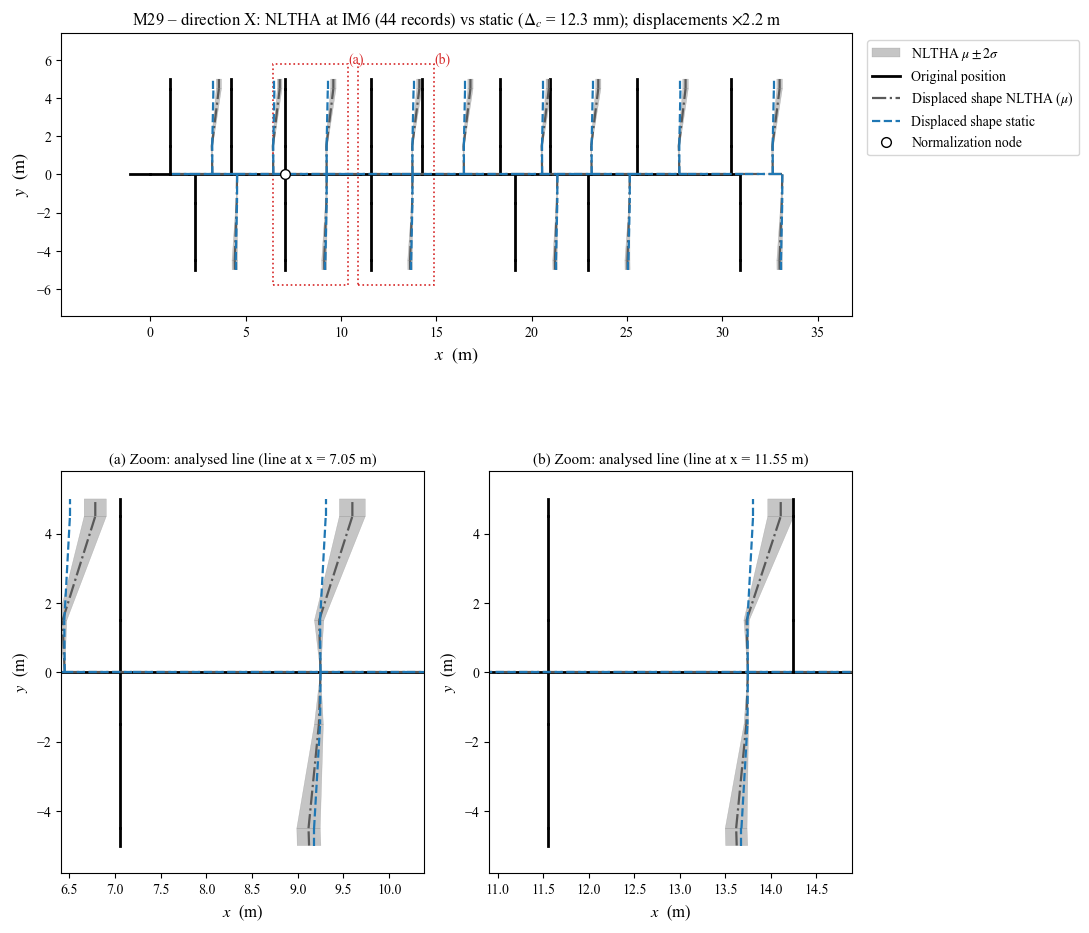

In [7]:
plot_displaced_shape(MODEL, 'X', SHAPE_IM, amp=AMP, dc_target=DC_TARGET)
plt.show()

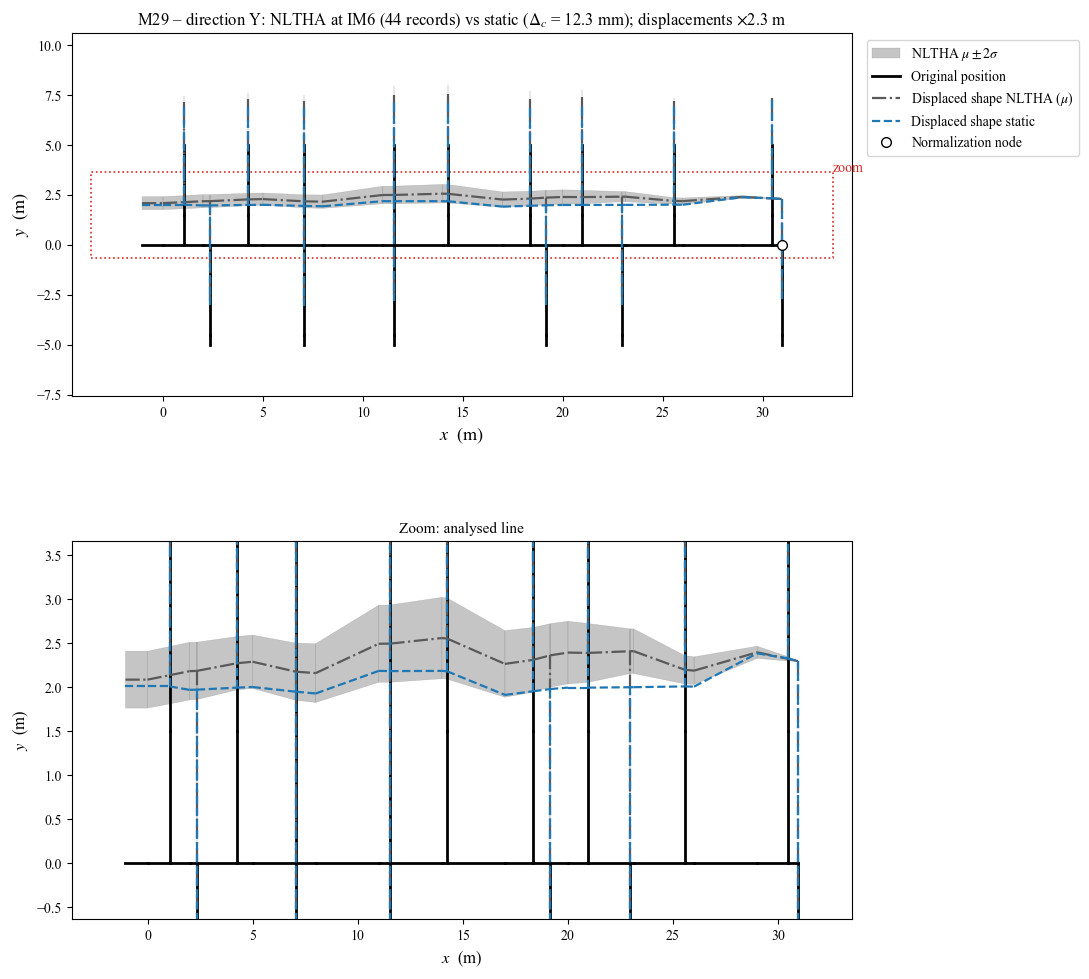

In [8]:
plot_displaced_shape(MODEL, 'Y', SHAPE_IM, amp=AMP, dc_target=DC_TARGET)
plt.show()